# Tutorial 2: The matter power spectrum, from inflation to today

The linear matter power spectrum is assembled in Galacticus exactly as in
the textbooks:

$$P(k, t) \;=\; P_\mathrm{primordial}(k)\; T^2(k)\; D^2(t),$$

with each factor an interchangeable `functionClass`: a primordial spectrum
(power law with optional running), a transfer function (analytic
Eisenstein & Hu, tabulated CAMB/CLASS, warm/fuzzy dark matter variants…),
and the linear growth factor. On top of these sits the filtered variance
$\sigma(M)$, whose normalization *is* the familiar $\sigma_8$.

This tutorial builds the full chain, then swaps in thermal warm dark
matter (WDM) to see free-streaming erase small-scale structure.

In [1]:
import os, sys

# Locate the Galacticus library interface. Two supported layouts:
#  * a Galacticus source tree built with
#      make GALACTICUS_BUILD_OPTION=lib libgalacticus.so
#    (galacticus.py at the tree root, the library under galacticus/lib/);
#  * an unpacked binary distribution (the `galacticus/` folder from
#    libgalacticus.tar.bz2, with python/ and lib/ inside it).
# Set GALACTICUS_LIBRARY_PATH to the directory CONTAINING the `galacticus/`
# folder if the auto-detection below does not fit your setup.
root = os.environ.get('GALACTICUS_LIBRARY_PATH',
                      os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
os.chdir(root)   # galacticus.py loads galacticus/lib/libgalacticus.so relative to here
for candidate in (root, os.path.join(root, 'galacticus', 'python')):
    if os.path.exists(os.path.join(candidate, 'galacticus.py')):
        sys.path.insert(0, candidate)
        break
else:
    raise RuntimeError(f"galacticus.py not found under {root} - build the library "
                       "(make GALACTICUS_BUILD_OPTION=lib libgalacticus.so) or set "
                       "GALACTICUS_LIBRARY_PATH")

import numpy as np
import matplotlib.pyplot as plt
import galacticus
print("Galacticus library interface loaded.")

Galacticus library interface loaded.


In [2]:
plt.rcParams.update({'figure.figsize': (7.0, 4.5), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

## The object graph

Note the pattern: each object receives the objects it depends on. This is
the same dependency graph Galacticus builds internally from a parameter
file when it runs a full model.

In [3]:
cosmologyParameters = galacticus.cosmologyParametersSimple(0.3, 0.045, 0.7, 2.78, 70.0)
cosmologyFunctions  = galacticus.cosmologyFunctionsMatterLambda(cosmologyParameters)
darkMatterParticle  = galacticus.darkMatterParticleCDM()

# Analytic CDM transfer function (Eisenstein & Hu 1999), with N_eff=3.046
# effective neutrino species of zero mass.
transferFunction = galacticus.transferFunctionEisensteinHu1999(
    3.046, 0.0, darkMatterParticle, cosmologyParameters, cosmologyFunctions)

linearGrowth = galacticus.linearGrowthCollisionlessMatter(cosmologyParameters, cosmologyFunctions)

# Primordial power spectrum: P(k) ~ k^0.965, no running; the reference
# wavenumber (1 Mpc^-1) anchors the running terms.
powerSpectrumPrimordial = galacticus.powerSpectrumPrimordialPowerLaw(0.965, 0.0, 0.0, 1.0, False)

# Combine primordial + transfer + growth.
powerSpectrum = galacticus.powerSpectrumPrimordialTransferredSimple(
    powerSpectrumPrimordial, transferFunction, linearGrowth)

ageToday = cosmologyFunctions.cosmicTime(1.0)
print(f"T(k=1 Mpc^-1) = {transferFunction.value(1.0):.4e}")
print(f"D(z=0) = {linearGrowth.value(time=ageToday):.3f} (normalized to unity today)")

T(k=1 Mpc^-1) = 2.4915e-03
D(z=0) = 1.000 (normalized to unity today)


## $\sigma(M)$ and the $\sigma_8$ normalization

`cosmologicalMassVarianceFilteredPower` integrates $P(k)$ under a top-hat
window to give the root-variance of the density field smoothed on mass
scale $M$ — and *sets the overall normalization* of the power spectrum from
the $\sigma_8$ you request.

In [4]:
powerSpectrumWindowFunction = galacticus.powerSpectrumWindowFunctionTopHat(cosmologyParameters)
cosmologicalMassVariance    = galacticus.cosmologicalMassVarianceFilteredPower(
    sigma8                                = 0.8,
    tolerance                             = 1.0e-4,
    toleranceTopHat                       = 1.0e-4,
    nonMonotonicIsFatal                   = True,
    integrationFailureIsFatal             = True,
    monotonicInterpolation                = False,
    rootVarianceLogarithmicGradientTolerance = 1.0e-4,
    truncateAtParticleHorizon             = False,
    storeTabulations                      = True,
    cosmologyParameters_                  = cosmologyParameters,
    cosmologyFunctions_                   = cosmologyFunctions,
    linearGrowth_                         = linearGrowth,
    powerSpectrumPrimordialTransferred_   = powerSpectrum,
    powerSpectrumWindowFunction_          = powerSpectrumWindowFunction,
)
print(f"sigma_8 (round trip)                  = {cosmologicalMassVariance.sigma8():.3f}")
print(f"sigma(M=1e12 Msun, z=0)               = {cosmologicalMassVariance.rootVariance(1.0e12, ageToday):.3f}")
print(f"M with sigma(M)=1 at z=0 (M_*, today) = {cosmologicalMassVariance.mass(1.0, ageToday):.3e} Msun")

sigma_8 (round trip)                  = 0.800
sigma(M=1e12 Msun, z=0)               = 2.145
M with sigma(M)=1 at z=0 (M_*, today) = 9.010e+13 Msun


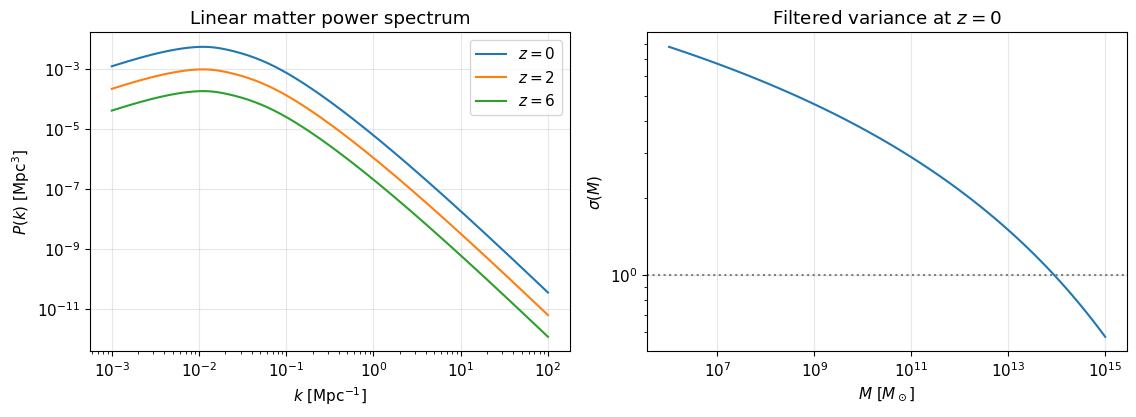

In [5]:
# P(k, z) at several epochs, and sigma(M) at z=0.
wavenumbers = np.logspace(-3, 2, 200)     # comoving Mpc^-1
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
for z in (0.0, 2.0, 6.0):
    t = cosmologyFunctions.cosmicTime(cosmologyFunctions.expansionFactorFromRedshift(z))
    P = np.array([powerSpectrum.power(k, t) for k in wavenumbers])
    axes[0].loglog(wavenumbers, P, label=f'$z={z:.0f}$')
axes[0].set_xlabel('$k$ [Mpc$^{-1}$]'); axes[0].set_ylabel('$P(k)$ [Mpc$^3$]')
axes[0].legend(); axes[0].set_title('Linear matter power spectrum')

masses = np.logspace(6, 15, 100)
sigma  = np.array([cosmologicalMassVariance.rootVariance(M, ageToday) for M in masses])
axes[1].loglog(masses, sigma)
axes[1].axhline(1.0, color='gray', ls=':')
axes[1].set_xlabel('$M$ [$M_\\odot$]'); axes[1].set_ylabel('$\\sigma(M)$')
axes[1].set_title('Filtered variance at $z=0$')
fig.tight_layout(); plt.show()

## Growth of structure

The growth factor $D(z)$ (normalized to unity today) quantifies how much
linear perturbations have grown. Matter domination gives
$D \propto a$; dark energy suppresses late-time growth below that scaling.

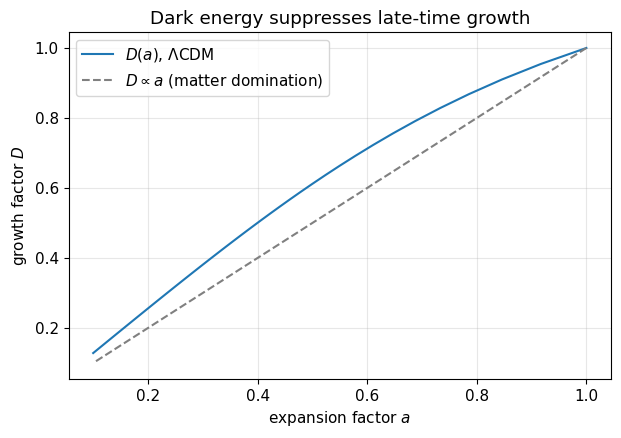

In [6]:
zGrid = np.linspace(0.0, 9.0, 100)
D = np.array([linearGrowth.value(expansionFactor=1.0/(1.0+z)) for z in zGrid])
plt.plot(1.0/(1.0+zGrid), D          , label='$D(a)$, $\\Lambda$CDM')
plt.plot(1.0/(1.0+zGrid), 1.0/(1.0+zGrid), ls='--', color='gray', label='$D\\propto a$ (matter domination)')
plt.xlabel('expansion factor $a$'); plt.ylabel('growth factor $D$'); plt.legend()
plt.title('Dark energy suppresses late-time growth')
plt.show()

## Warm dark matter: free-streaming cuts off the spectrum

A thermal-relic WDM particle free-streams out of small-scale perturbations.
Galacticus applies the Bode et al. (2001) fitting form on top of any CDM
transfer function; the particle physics enters through
`darkMatterParticleWDMThermal` (mass in keV, effective degrees of freedom).

Two diagnostic scales come straight off the transfer-function object:

* `halfModeMass()` — the mass scale where $T_\mathrm{WDM}/T_\mathrm{CDM} = 1/2$,
  the standard proxy for where the halo mass function is suppressed;
* `wavenumbersLocalMinima()` — positions of local minima of $T(k)$, non-empty
  for *oscillatory* models (fuzzy dark matter, CLASS-computed spectra); for
  the smooth Bode et al. form it correctly returns an empty array.

 particle mass     half-mode mass
          1 keV       1.159e+10 Msun
          3 keV       2.618e+08 Msun
         10 keV       4.112e+06 Msun


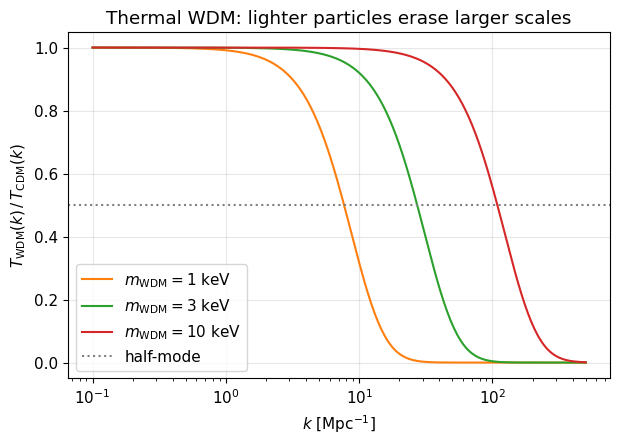

In [7]:
fig, ax = plt.subplots()
kGrid = np.logspace(-1, 2.7, 300)
print(f"{'particle mass':>14s} {'half-mode mass':>18s}")
for massWDM, color in ((1.0, 'C1'), (3.0, 'C2'), (10.0, 'C3')):
    particleWDM = galacticus.darkMatterParticleWDMThermal(massWDM, 1.5, cosmologyParameters)
    transferFunctionWDM = galacticus.transferFunctionBode2001(
        transferFunction,      # the CDM transfer function to modify
        1,                     # cut-off model: barkana2001
        0.359, 3.81, 1.1,      # epsilon, eta, nu (Barkana et al. 2001 fit)
        ageToday, cosmologyParameters, particleWDM, cosmologyFunctions)
    ratio = np.array([transferFunctionWDM.value(k)/transferFunction.value(k) for k in kGrid])
    ax.semilogx(kGrid, ratio, color=color, label=f'$m_\\mathrm{{WDM}}={massWDM:.0f}$ keV')
    print(f"{massWDM:11.0f} keV {transferFunctionWDM.halfModeMass():15.3e} Msun")
    # Smooth cut-off => no oscillations => empty minima array.
    assert transferFunctionWDM.wavenumbersLocalMinima().size == 0
ax.axhline(0.5, color='gray', ls=':', label='half-mode')
ax.set_xlabel('$k$ [Mpc$^{-1}$]'); ax.set_ylabel('$T_\\mathrm{WDM}(k)\\,/\\,T_\\mathrm{CDM}(k)$')
ax.set_ylim(-0.05, 1.05); ax.legend()
ax.set_title('Thermal WDM: lighter particles erase larger scales')
plt.show()

The half-mode mass scales steeply with particle mass (roughly
$M_\mathrm{hm} \propto m_\mathrm{WDM}^{-3.33}$) — a 1 keV relic wipes out
dwarf-galaxy-scale halos, while 10 keV is nearly indistinguishable from CDM
above $10^6\,M_\odot$. Tutorial 3 turns these spectra into halo mass
functions.